
Weights and capital allocation for each ticker:
 - AGG   : 0.304 -> 3,039.08
 - EEM   : 0.012 -> 115.62
 - GLD   : 0.062 -> 615.55
 - IWM   : 0.047 -> 467.92
 - QQQ   : 0.100 -> 1,000.11
 - SPY   : 0.104 -> 1,043.52
 - TIP   : 0.245 -> 2,451.32
 - TLT   : 0.034 -> 342.89
 - VEA   : 0.046 -> 462.50
 - VNQ   : 0.046 -> 461.50

Expected annual portfolio return: 7.270%
Expected annual portfolio volatility: 7.310%
Sharpe ratio: 0.31


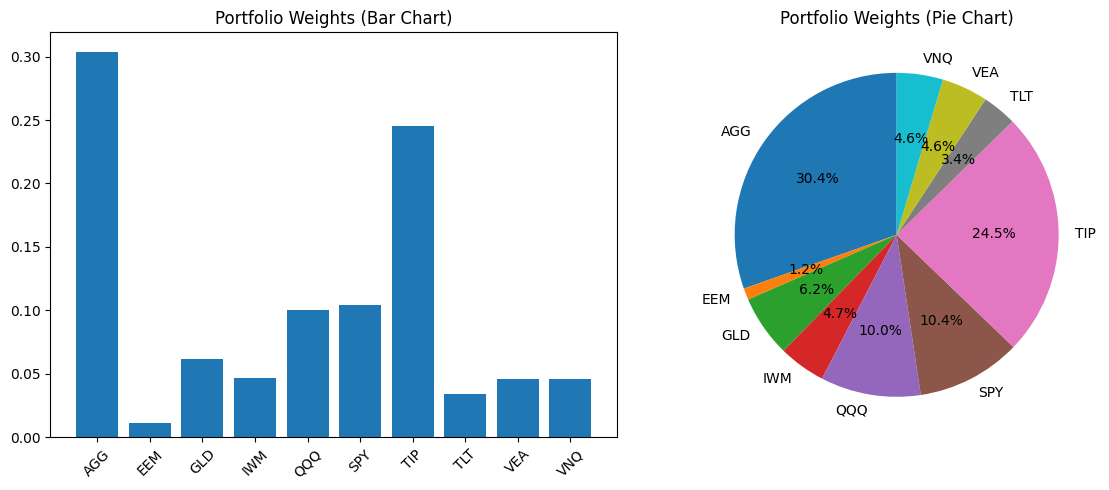

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# USER INPUTS:
tickers = ["SPY", "QQQ", "IWM", "VEA", "EEM", "AGG", "TLT", "GLD", "VNQ", "TIP"]        # Choose your tickers.
start_date = "2010-01-01"           # Choose start date for data collection.
end_date = None                     # Choose end date for data collection. Write "None" if you want the data to be collected until present day.
investable_capital = 10_000         # Choose how much capital to allocate (currency is irrelevant).
risk_tolerance = 5                  # Specify rsik tolerance on a scale of 1 (conservative) to 10 (aggressive).
risk_free_rate = 0.05               # Specify annual risk-free rate.

# Download data, calculate daily returns and annualsie returns and volatility.
data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)["Close"]
data = data.dropna()
daily_returns = data.pct_change().dropna()
trading_days = 252
annual_mean = daily_returns.mean() * trading_days
annual_volatility = daily_returns.std() * np.sqrt(trading_days)

# Define the signals: inverse volatility and return-per-volatility.

# inverse volatility: this gives more weight to less volatile assets.
inverse_volatility = 1 / annual_volatility

# return-per-volatility: this gives more weight to assets that historically delivered more return per unit of risk.
return_volatility = annual_mean / annual_volatility

# Normalise the signals
def normalize_positive(series):
    """ This function makes every value positive and scales so values sum to 1. This makes both signals interpretable together."""
    signal = series.copy().astype(float)
    signal = signal - signal.min() + 1e-9
    return signal / signal.sum()
inverse_volatility_norm = normalize_positive(inverse_volatility)
return_volatility_norm = normalize_positive(return_volatility)


# Combine signals according to risk tolerance:
risk_level = int(np.clip(risk_tolerance, 1, 10))

# Combine risk tolerance and conservative/aggressive mix and combine signals.
conservative_weight = (11 - risk_level) / 10.0
aggressive_weight = (risk_level - 1) / 9.0
combined_signal = conservative_weight * inverse_volatility_norm + aggressive_weight * return_volatility_norm

# Ensure that there are no negative numbers to ensure long-only portfolio.
combined_signal = combined_signal.clip(lower=0)
weights = combined_signal / combined_signal.sum()

# Convert weights to monetary allocation amounts.
allocation_amounts = (weights * investable_capital).round(2)

# Calculate expected portfolio return, annual covariance matrix, portfolio volatility and a simple Sharpe ratio.
portfolio_return = np.dot(weights.values, annual_mean.values)
covariance_annual = daily_returns.cov() * trading_days
portfolio_volatility = np.sqrt(weights.values @ covariance_annual.values @ weights.values.T)
sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility if portfolio_volatility > 0 else np.nan


print("\nWeights and capital allocation for each ticker:")
for ticker, weight, monetary_allocation in zip(weights.index, weights.values, allocation_amounts.values):
    print(f" - {ticker:5s} : {weight:.3f} -> {monetary_allocation:,.2f}")

print(f"\nExpected annual portfolio return: {portfolio_return:.3%}")
print(f"Expected annual portfolio volatility: {portfolio_volatility:.3%}")
print(f"Sharpe ratio: {sharpe:.2f}")

# Plot charts for the data.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart:
axes[0].bar(weights.index, weights.values)
axes[0].set_title("Portfolio Weights (Bar Chart)")
axes[0].tick_params(axis='x', rotation=45)

# Pie chart:
axes[1].pie(weights.values, labels=weights.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Portfolio Weights (Pie Chart)")

plt.tight_layout()
plt.show()





### Out-of-Sample Backtest Results

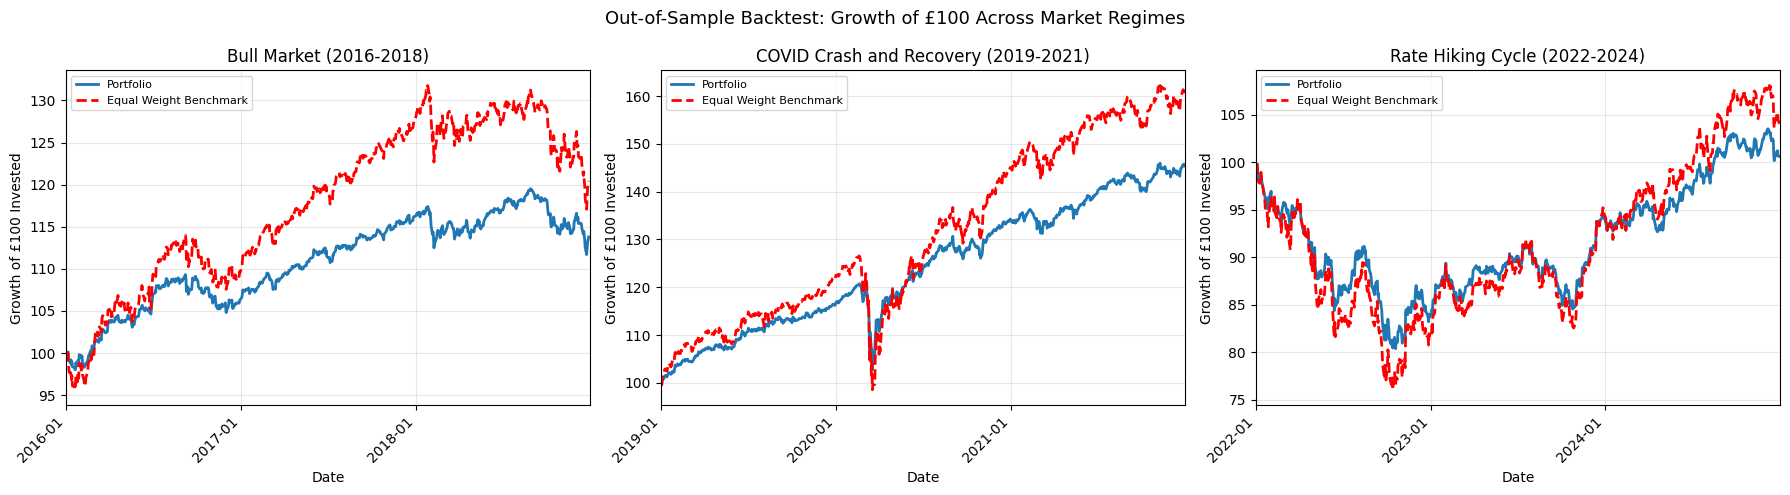

                                      Model Return  Model Volatility  \
Bull Market (2016-2018)                      0.044             0.047   
COVID Crash and Recovery (2019-2021)         0.134             0.082   
Rate Hiking Cycle (2022-2024)                0.002             0.089   

                                      Model Sharpe  Benchmark Return  \
Bull Market (2016-2018)                     -0.124             0.064   
COVID Crash and Recovery (2019-2021)         1.016             0.173   
Rate Hiking Cycle (2022-2024)               -0.538             0.013   

                                      Benchmark Volatility  Benchmark Sharpe  
Bull Market (2016-2018)                              0.080             0.179  
COVID Crash and Recovery (2019-2021)                 0.134             0.918  
Rate Hiking Cycle (2022-2024)                        0.123            -0.299  


In [ ]:
import matplotlib.dates as mdates

# ------------- Backtest ----------------

splits = {"Bull Market (2016-2018)": ("2010-01-01", "2015-12-31", "2016-01-01", "2018-12-31"),
          "COVID Crash and Recovery (2019-2021)": ("2010-01-01", "2018-12-31", "2019-01-01", "2021-12-31"),
          "Rate Hiking Cycle (2022-2024)": ("2010-01-01", "2021-12-31", "2022-01-01", "2024-12-31")}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results = {}
for ax, (period_name, (train_start, train_end, test_start, test_end)) in zip(axes, splits.items()):

  # Calculate weights on training data
  train_data = yf.download(tickers, start=train_start, end=train_end, progress=False, auto_adjust=True)["Close"].dropna()
  train_returns = train_data.pct_change().dropna()
  train_mean = train_returns.mean() * 252
  train_vol = train_returns.std() * np.sqrt(252)
  inv_vol = normalize_positive(1 / train_vol)
  ret_vol = normalize_positive(train_mean / train_vol)
  combined = conservative_weight * inv_vol + aggressive_weight * ret_vol
  combined = combined.clip(lower=0)
  weights = combined / combined.sum()

  # Test weights on unseen data
  test_data = yf.download(tickers, start=test_start, end=test_end, progress=False, auto_adjust=True)["Close"].dropna()
  test_returns = test_data.pct_change().dropna()

  # Daily Portfolio and benchmark returns
  aligned_weights = pd.Series(weights.values, index=weights.index)
  aligned_weights = aligned_weights.reindex(test_returns.columns).fillna(0)
  portfolio_returns = pd.Series((test_returns * aligned_weights).sum(axis=1))
  equal_weights = np.repeat(1/len(tickers), len(tickers))
  benchmark_returns = pd.Series(test_returns.values @ equal_weights, index=test_returns.index)

  # Growth of £100
  portfolio_growth = 100 * (1 + portfolio_returns).cumprod()
  benchmark_growth = 100 * (1 + benchmark_returns).cumprod()

  # Performance Statistics
  years = len(portfolio_returns) / 252
  port_return = (portfolio_growth.iloc[-1] / 100)**(1/years) - 1
  bench_return = (benchmark_growth.iloc[-1] / 100)**(1/years) - 1 # Use .iloc[-1] for consistency with portfolio_growth
  port_vol = portfolio_returns.std() * np.sqrt(252)
  bench_vol = pd.Series(benchmark_returns).std() * np.sqrt(252)
  port_sharpe = (port_return - risk_free_rate) / port_vol
  bench_sharpe = (bench_return - risk_free_rate) / bench_vol

  results[period_name] = {"Model Return": round(port_return, 3),
                          "Model Volatility": round(port_vol, 3),
                          "Model Sharpe": round(port_sharpe, 3),
                          "Benchmark Return": round(bench_return, 3),
                          "Benchmark Volatility": round(bench_vol, 3),
                          "Benchmark Sharpe": round(bench_sharpe, 3)}

  # Plot Growth of £100
  ax.plot(portfolio_growth, label="Portfolio", linewidth=2)
  ax.plot(benchmark_growth, label="Equal Weight Benchmark", linestyle="--", color='red', linewidth=2) # Distinct color and linewidth
  ax.set_title(period_name)
  ax.set_ylabel("Growth of £100 Invested")
  ax.set_xlabel("Date")
  ax.legend(fontsize=8)
  ax.grid(alpha=0.3)
  # Set x-axis limits to match the test period
  ax.set_xlim(pd.to_datetime(test_start), pd.to_datetime(test_end))
  # Format x-axis dates for clarity
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
  ax.xaxis.set_major_locator(mdates.YearLocator()) # Show yearly ticks
  plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.suptitle("Out-of-Sample Backtest: Growth of £100 Across Market Regimes", fontsize=13)
plt.tight_layout()
plt.show()

# Results Table
results_df = pd.DataFrame(results).T
print(results_df)